<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/Face_Mask_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 141MB/s]



In [7]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [12]:
mask = os.listdir('/content/data/with_mask')
print(mask[0:5])
without_mask = os.listdir('/content/data/without_mask')
print(without_mask[0:5])

['with_mask_3173.jpg', 'with_mask_315.jpg', 'with_mask_1887.jpg', 'with_mask_176.jpg', 'with_mask_3197.jpg']
['without_mask_2223.jpg', 'without_mask_2393.jpg', 'without_mask_2820.jpg', 'without_mask_34.jpg', 'without_mask_3485.jpg']


In [13]:
print(len(mask))
print(len(without_mask))

3725
3828


In [15]:
mask_label = [1]* 3725
without_mask_label = [0]* 3828

In [16]:
print(mask_label[0:5])
print(without_mask_label[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [18]:
labels = mask_label + without_mask_label
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


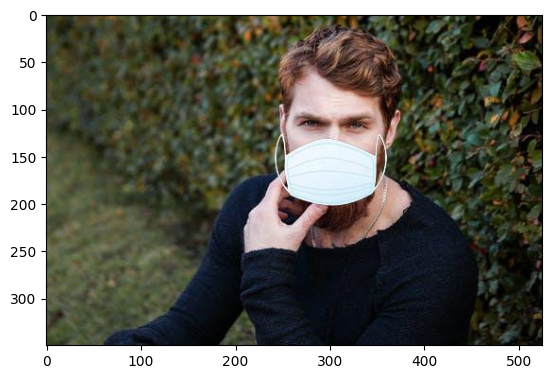

In [21]:
img = mpimg.imread('/content/data/with_mask/with_mask_1.jpg')
img_plot = plt.imshow(img)
plt.show()

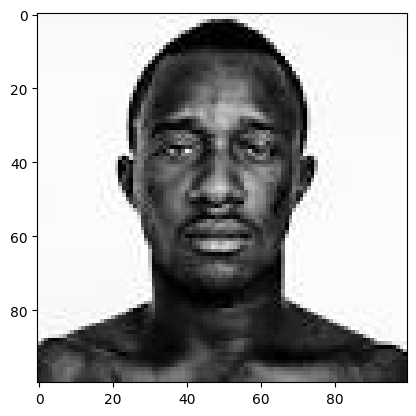

In [22]:
img = mpimg.imread('/content/data/without_mask/without_mask_1.jpg')
img_plot = plt.imshow(img)
plt.show()

In [25]:
import os

with_mask_path = '/content/data/with_mask/'
without_mask_path = '/content/data/without_mask/'

# Re-initializing mask and without_mask with actual filenames
mask = os.listdir(with_mask_path)
without_mask = os.listdir(without_mask_path)

data = []
for img_name in mask:
  img = Image.open(with_mask_path + img_name)
  img = img.resize((128,128))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)

for img_name in without_mask:
  img = Image.open(without_mask_path + img_name)
  img = img.resize((128,128))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [26]:
len(data)

7553

In [27]:
type(data)

list

array([[[131, 133, 134],
        [ 38,  39,  40],
        [ 43,  45,  44],
        ...,
        [ 41,  43,  42],
        [ 36,  38,  37],
        [100, 102, 101]],

       [[131, 133, 133],
        [ 38,  40,  40],
        [ 44,  45,  44],
        ...,
        [ 42,  44,  43],
        [ 36,  38,  37],
        [100, 101, 101]],

       [[132, 133, 133],
        [ 37,  40,  39],
        [ 43,  45,  44],
        ...,
        [ 41,  43,  42],
        [ 35,  37,  36],
        [ 99, 102, 101]],

       ...,

       [[172, 213, 231],
        [109, 182, 217],
        [114, 187, 221],
        ...,
        [176, 176, 176],
        [178, 178, 178],
        [202, 202, 202]],

       [[171, 214, 231],
        [107, 182, 217],
        [110, 185, 220],
        ...,
        [179, 179, 179],
        [180, 180, 180],
        [202, 202, 202]],

       [[171, 214, 231],
        [104, 181, 217],
        [106, 183, 219],
        ...,
        [182, 183, 183],
        [181, 182, 182],
        [202, 202, 203]]], dtype=uint8)
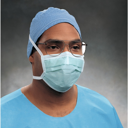

In [29]:
data[0]

In [30]:
X = np.array(data)
Y = np.array(labels)

In [31]:
type(X)

numpy.ndarray

In [32]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [34]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [35]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [37]:
X_test_scaled[2]

array([[[0.09803922, 0.09411765, 0.08627451],
        [0.09803922, 0.09411765, 0.08627451],
        [0.09411765, 0.08627451, 0.08235294],
        ...,
        [0.42745098, 0.30196078, 0.2       ],
        [0.43529412, 0.30588235, 0.21176471],
        [0.4745098 , 0.3372549 , 0.24705882]],

       [[0.09411765, 0.09019608, 0.08627451],
        [0.08627451, 0.08235294, 0.08235294],
        [0.08235294, 0.07843137, 0.07843137],
        ...,
        [0.40392157, 0.2745098 , 0.16862745],
        [0.40784314, 0.28235294, 0.17647059],
        [0.45882353, 0.32156863, 0.22352941]],

       [[0.08235294, 0.08235294, 0.08235294],
        [0.0745098 , 0.0745098 , 0.0745098 ],
        [0.07058824, 0.07058824, 0.07058824],
        ...,
        [0.42745098, 0.29411765, 0.18431373],
        [0.38431373, 0.25098039, 0.14509804],
        [0.40784314, 0.2745098 , 0.16862745]],

       ...,

       [[0.32941176, 0.31372549, 0.27843137],
        [0.49803922, 0.48235294, 0.44705882],
        [0.67058824, 0

In [38]:
import tensorflow as tf
from tensorflow import keras

In [39]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])

In [44]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 148s 853ms/step - acc: 0.8049 - loss: 0.4598 - val_acc: 0.8331 - val_loss: 0.3533
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 136s 799ms/step - acc: 0.8821 - loss: 0.2836 - val_acc: 0.8860 - val_loss: 0.2733
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 137s 773ms/step - acc: 0.9060 - loss: 0.2426 - val_acc: 0.8909 - val_loss: 0.2518
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 127s 750ms/step - acc: 0.9193 - loss: 0.2137 - val_acc: 0.8893 - val_loss: 0.2729
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 127s 746ms/step - acc: 0.9342 - loss: 0.1770 - val_acc: 0.9124 - val_loss: 0.2498


In [45]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - acc: 0.9239 - loss: 0.2201
Test Accuracy = 0.9238914847373962


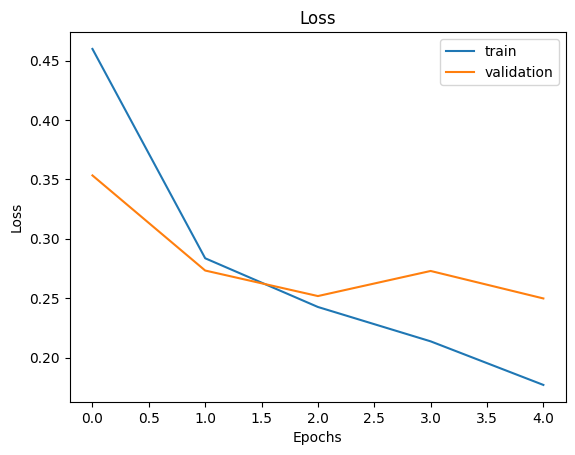

In [46]:
h = history
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

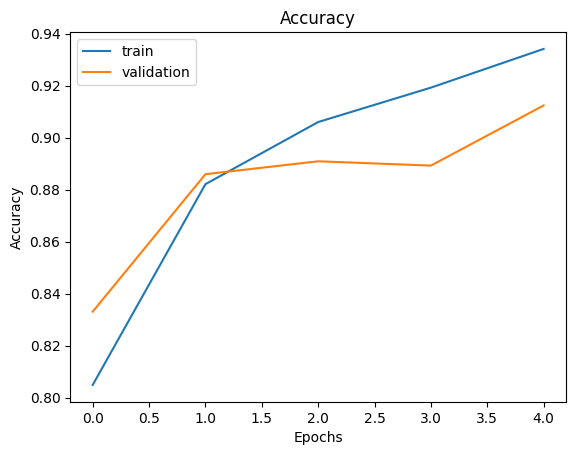

In [47]:
plt.plot(h.history['acc'])
plt.plot(h.history['val_acc'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

Enter the path of the image to be tested: /content/data/with_mask/with_mask_1045.jpg


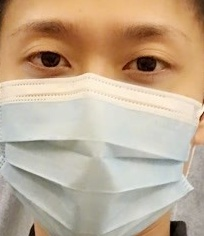

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[0.51355356 0.49739894]]
0
The person in the image is not wearing a mask


In [52]:
input_img_path = input('Enter the path of the image to be tested: ')

input_img = cv2.imread(input_img_path)
cv2_imshow(input_img)
input_img_resized = cv2.resize(input_img, (128,128))
input_img_scaled = input_img_resized/255
input_img_reshaped = np.reshape(input_img_scaled, [1,128,128,3])

input_prediction = model.predict(input_img_reshaped)
print(input_prediction)

input_pred_label = np.argmax(input_prediction)
print(input_pred_label)

if input_pred_label == 1:
  print('The person in the image is wearing a mask')
else:
  print('The person in the image is not wearing a mask')


48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step


<Axes: >

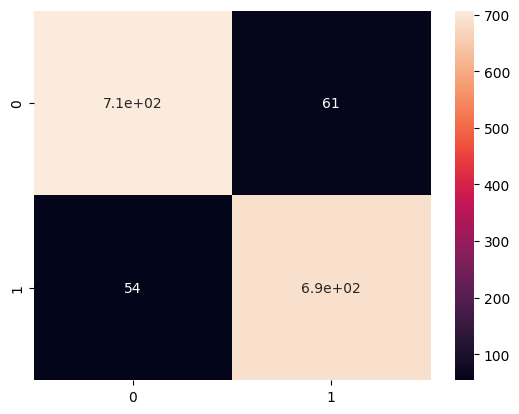

In [54]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(X_test_scaled)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True)











In [55]:
from sklearn.metrics import classification_report

# Assuming Y_test and y_pred (from np.argmax(Y_pred, axis=1)) are already defined from previous cells
print(classification_report(Y_test, y_pred, target_names=['Without Mask', 'With Mask']))

              precision    recall  f1-score   support

Without Mask       0.93      0.92      0.92       768
   With Mask       0.92      0.93      0.92       743

    accuracy                           0.92      1511
   macro avg       0.92      0.92      0.92      1511
weighted avg       0.92      0.92      0.92      1511



In [56]:
# Find indices of misclassified images
misclassified_indices = np.where(Y_test != y_pred)[0]

# Get the misclassified images, true labels, and predicted labels
misclassified_images = X_test[misclassified_indices]
misclassified_true_labels = Y_test[misclassified_indices]
misclassified_predicted_labels = y_pred[misclassified_indices]

print(f"Total misclassified images: {len(misclassified_indices)}")

Total misclassified images: 115


### Sample of Misclassified Images
Let's visualize a few of these misclassified images to understand the errors.

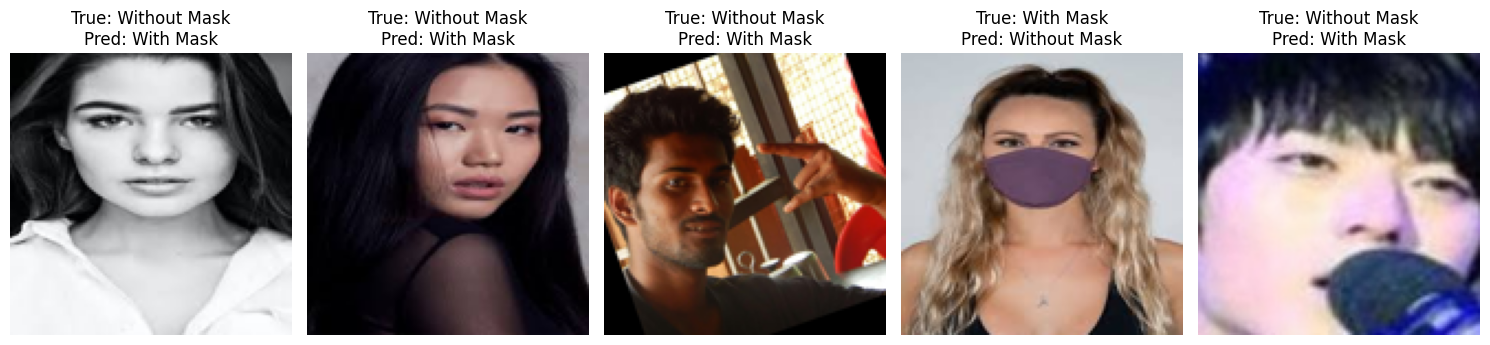

In [57]:
import random

# Number of sample misclassified images to display
num_samples = 5

# Select random indices from the misclassified images
sample_indices = random.sample(range(len(misclassified_indices)), min(num_samples, len(misclassified_indices)))

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(misclassified_images[idx]) # X_test contains original pixel values, not scaled
    true_label = 'With Mask' if misclassified_true_labels[idx] == 1 else 'Without Mask'
    predicted_label = 'With Mask' if misclassified_predicted_labels[idx] == 1 else 'Without Mask'
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [64]:
def predict_multiple_images(image_paths):
    if not image_paths:
        print("No image paths provided.")
        return

    # Ensure we don't process more than 10 images at a time
    if len(image_paths) > 10:
        print("Warning: Processing only the first 10 images.")
        image_paths = image_paths[:10]

    preprocessed_images = []
    for img_path in image_paths:
        input_img = cv2.imread(img_path)
        if input_img is None:
            print(f"Error: Could not load image from {img_path}. Skipping.")
            continue

        # Convert BGR image to RGB for correct display with matplotlib
        input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)

        input_img_resized = cv2.resize(input_img_rgb, (128, 128))
        input_img_scaled = input_img_resized / 255.0  # Scale pixel values
        preprocessed_images.append(input_img_scaled)

    if not preprocessed_images:
        print("No valid images to process.")
        return

    # Convert list of images to a numpy array
    preprocessed_images_array = np.array(preprocessed_images)

    # Make predictions
    predictions = model.predict(preprocessed_images_array)
    predicted_labels = np.argmax(predictions, axis=1)

    # Display images with predictions
    plt.figure(figsize=(15, 6))
    for i, (img_array, pred_label, img_path) in enumerate(zip(preprocessed_images_array, predicted_labels, image_paths)):
        plt.subplot(2, 5, i + 1) # Adjust subplot grid for up to 10 images
        plt.imshow(img_array) # Display scaled image
        label_text = 'With Mask' if pred_label == 1 else 'Without Mask'
        plt.title(f"Pred: {label_text}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Let's test the `predict_multiple_images` function with a sample of 10 images (5 with masks and 5 without masks) from your dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


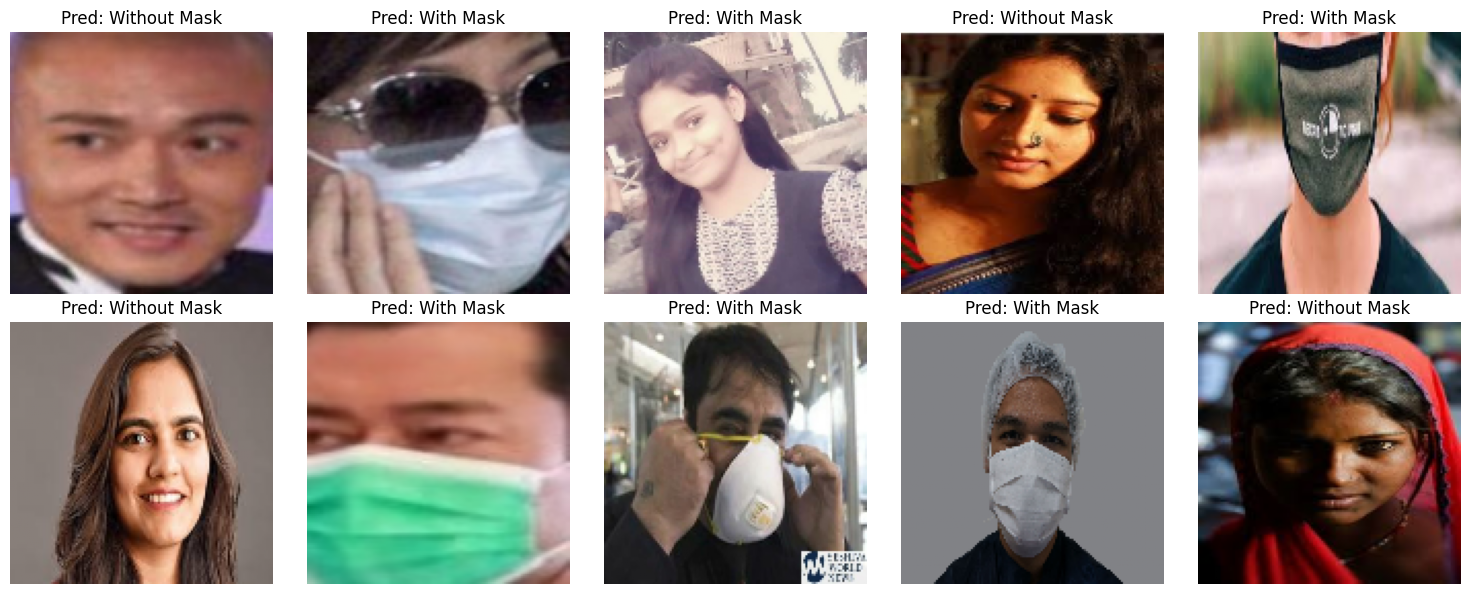

In [65]:
import random
import os # Ensure os is imported as it is used here

# Re-initialize mask and without_mask lists to ensure they contain filenames
mask_files = os.listdir('/content/data/with_mask/')
without_mask_files = os.listdir('/content/data/without_mask/')

sample_with_mask_paths = [os.path.join('/content/data/with_mask/', f) for f in random.sample(mask_files, 5)]
sample_without_mask_paths = [os.path.join('/content/data/without_mask/', f) for f in random.sample(without_mask_files, 5)]

# Combine them for testing
test_image_paths = sample_with_mask_paths + sample_without_mask_paths
random.shuffle(test_image_paths) # Shuffle to mix them up

# Explicitly restore the built-in zip function
# This is necessary because 'zip' was previously shadowed by the ZipFile class
# in the global scope, causing the TypeError.
zip = __builtins__.zip

# Call the new prediction system
predict_multiple_images(test_image_paths)